In [168]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [169]:
city = pd.read_csv('city_day.csv')
crop = pd.read_csv('crop_production.csv') 

<b>Reading the dataset and converting the dataset into a dataframe</b>

In [170]:
print("City DataFrame:")
print(city.head())

print("\nCrop DataFrame:")
print(crop.head())

City DataFrame:
        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.36     0.00     0.02    0.00  NaN        NaN  
1   34.06     3.68     5.50    3.77  NaN        NaN  
2   30.70     6.80    16.40    2.25  NaN        NaN  
3   36.08     4.43    10.14    1.00  NaN        NaN  
4   39.31     7.01    18.89    2.78  NaN        NaN  

Crop DataFrame:
                    State_Name District_Name  Crop_Year       Season  \
0  Andaman and Nicobar Islands      NICOBARS       2000  Kharif        
1  Andaman a

<b>Printing First 5 observations of city and crop dataset</b>

<b>Task 1</b>

In [171]:
print("City")
print("Size: ", city.shape)
print("\n")
print("Columns: ", city.columns)
print("\n")
print("Columns Types: ")
print(city.dtypes)
print("\n")
print(city.describe())
print("\n")
print(city.info())
print("\n")
print("Null values in City DataFrame: ")
print(city.isnull().sum())
print("\n")
print("Duplicates in City DataFrame: ")
print(city.duplicated().sum())
print("\n")
city_pct = (city.isnull().sum() / len(city) * 100).round(2)
null_df = pd.DataFrame({'Missing Count': city.isnull().sum(), 'Missing %': city_pct})
print(null_df[null_df['Missing Count'] > 0])

City
Size:  (29531, 16)


Columns:  Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')


Columns Types: 
City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object


              PM2.5          PM10            NO           NO2           NOx  \
count  24933.000000  18391.000000  25949.000000  25946.000000  25346.000000   
mean      67.450578    118.127103     17.574730     28.560659     32.309123   
std       64.661449     90.605110     22.785846     24.474746     31.646011   
min        0.040000      0.010000      0.020000      0.010000      0.000000   
25%       28.8

<b>Inference:</b><br>
<b>The City dataset contain 29531 observations and 16 attributes</b><br>
<b>The Colums with null values are</b><br>
PM2.5 = 4598<br>
PM10 = 11140<br>
NO = 3582<br>
NO2 = 3585<br>
NOx = 4185<br>
NH3 = 10328<br>
CO = 2059<br>
SO2 = 3854<br>
O3 = 4022<br>
Benzene = 5623<br>
Toluene = 8041<br>
Xylene = 18109<br>
AQI = 4681<br>
AQI_Bucket = 4681<br>
<b>The City dataset does not contain any duplicate values</b><br>

Xylene is missing 61.32% values which should be dropped as a modelling feature.<br>

AQI and AQI_Bucket both are missing 15.85% combined values which is a core feature and can not be filled by itself<br>

PM10 is missing 37.72% of null values.<br>

Date is stored as object that must be converted into DateTime before any time series analysis.<br>

Max Value of AQI is 2049 which is impossible because max value of AQI can be 500 leading to a data error<br>

In [172]:
print("Crop\n")
print("Size: \n", crop.shape)
print("Columns: \n", crop.columns)
print("\n")
print("Columns Types: ")
print(crop.dtypes)
print("\n")
print(crop.describe())
print("\n")
print(crop.info())
print("\n")
print("Null values in Crop DataFrame: ")
print(crop.isnull().sum())
print("\n")
print("Duplicates in Crop DataFrame: ")
print(crop.duplicated().sum())

crop_pct = (crop.isnull().sum() / len(crop) * 100).round(2)
null_df_crop = pd.DataFrame({'Missing Count': crop.isnull().sum(), 'Missing %': crop_pct})
print(null_df_crop[null_df_crop['Missing Count'] > 0])

print(sorted(crop['State_Name'].unique()))

Crop

Size: 
 (246091, 7)
Columns: 
 Index(['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area',
       'Production'],
      dtype='object')


Columns Types: 
State_Name        object
District_Name     object
Crop_Year          int64
Season            object
Crop              object
Area             float64
Production       float64
dtype: object


           Crop_Year          Area    Production
count  246091.000000  2.460910e+05  2.423610e+05
mean     2005.643018  1.200282e+04  5.825034e+05
std         4.952164  5.052340e+04  1.706581e+07
min      1997.000000  4.000000e-02  0.000000e+00
25%      2002.000000  8.000000e+01  8.800000e+01
50%      2006.000000  5.820000e+02  7.290000e+02
75%      2010.000000  4.392000e+03  7.023000e+03
max      2015.000000  8.580100e+06  1.250800e+09


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         -------------- 

<b>Inference:</b><br>
<b>The Crop dataset contain 246091 observations and 7 attributes</b><br>
<b>The Colums with null values are</b><br>
Production = 3730<br>
<b>The Crop dataset does not contain any duplicate values</b><br>
Production is missing 1.5% it ca be filled with median by crop type<br>

<b>Task 2</b>

In [173]:
print("Null values in City Dataset: ")
print(city.isnull().sum())
print("\n")

city_clean = city.copy()

city_clean = city_clean.drop(columns = ['Xylene', 'AQI_Bucket'])

cols = ['AQI', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx',
        'NH3', 'CO', 'SO2', 'O3',
        'Benzene', 'Toluene']

for col in cols:
    city_clean[col] = city_clean.groupby('City')[col].transform(
        lambda x: x.fillna(x.median())
    )

    city_clean[col] = city_clean[col].fillna(
        city_clean[col].median()
    )

print(city_clean.isnull().sum())

city_clean['Date'] = pd.to_datetime(city_clean['Date'], errors='coerce')

Null values in City Dataset: 
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64


City       0
Date       0
PM2.5      0
PM10       0
NO         0
NO2        0
NOx        0
NH3        0
CO         0
SO2        0
O3         0
Benzene    0
Toluene    0
AQI        0
dtype: int64


PM2.5 filled with median group by city because median is robust to extremes<br>
PM10 filled with median group by city because PM10 is important feature and dropping it will loose too much data<br>
NO, NO2, NOx filled with median group by city as they are correlated<br>
NH3 filled with median group by city as dropping will loose 35% of the observations<br>
CO filled with median group by city<br>
SO2, Benzene, Toluene and O3 filled with median as mean > median which states that there are high outliers in the datasets and medan is robust to extreme outliers<br>
Xylene missing 60% of the values filling those null values can lead inconsistent dataset so that column is dropped<br>
AQI is filled with median by city as different city has different AQI<br>
AQI_Bucket is categorical column which can not be dropped. 

In [174]:
print("Null values in Crop Dataset: ")
print(crop.isnull().sum())
print("\n")

crop_clean = crop.copy()

crop_clean['Production'] = crop_clean.groupby(['Crop', 'Season'])['Production'].transform(
    lambda x: x.fillna(x.median())
)

crop_clean['Production'] = crop_clean['Production'].fillna(crop_clean['Production'].median())

print('Null values in Crop Dataset After Cleaning:')
print(crop_clean.isnull().sum())

Null values in Crop Dataset: 
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64


Null values in Crop Dataset After Cleaning:
State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
dtype: int64


Production is filled with median group by crop and season before taking the 
median because different crops in different seasons produce very different quantitie

<b>Task 3</b>

A merge() in pandas uses exact string matching. 'Tamil Nadu' and 'Tamil Nadu ' (trailing space) are treated as different keys. The merge drops all rows from the right dataframe that carry the space producing incorrect NaN filled rows or missing data with no error message.<br>


Strip whitespace from all state-name columns in both files<br>
Title case normalisation to catch capitalisation variants<br>
Map known old names (eg. 'Orissa' to 'Odisha', 'Uttaranchal' to 'Uttarakhand')<br>
Build a city to state lookup for the city file<br>

In [175]:
crop_merge = crop_clean.copy()
city_merge = city_clean.copy()


print("Crop states with leading/trailing spaces:")
space_states = [s for s in crop_merge['State_Name'].unique()
                if s != s.strip()]
print(space_states)

crop_merge['State_Name'] = crop_merge['State_Name'].str.strip().str.title()

state_rename_map = {
    'Orissa': 'Odisha',
    'Uttaranchal': 'Uttarakhand',
    'Pondicherry': 'Puducherry'
}

crop_merge['State_Name'] = crop_merge['State_Name'].replace(state_rename_map)

c_to_s = {
    'Ahmedabad': 'Gujarat', 'Aizawl': 'Mizoram', 'Amaravati': 'Andhra Pradesh', 'Amritsar': 'Punjab', 'Bengaluru': 'Karnataka',
    'Bhopal': 'Madhya Pradesh', 'Brajrajnagar': 'Odisha', 'Chandigarh': 'Chandigarh', 'Chennai': 'Tamil Nadu', 'Coimbatore': 'Tamil Nadu',
    'Delhi': 'Delhi', 'Ernakulam': 'Kerala', 'Gurugram': 'Haryana', 'Guwahati': 'Assam', 'Hyderabad': 'Telangana', 'Jaipur': 'Rajasthan',
    'Jorapokhar': 'Jharkhand', 'Kochi': 'Kerala', 'Kolkata': 'West Bengal', 'Lucknow': 'Uttar Pradesh', 'Mumbai': 'Maharashtra', 'Patna': 'Bihar',
    'Shillong': 'Meghalaya', 'Talcher': 'Odisha', 'Thiruvananthapuram': 'Kerala', 'Visakhapatnam': 'Andhra Pradesh'
}

city_merge['State'] = city_merge['City'].map(c_to_s)

print("Cities without state mapping:")
print(city_merge[city_merge['State'].isna()]['City'].unique())

crop_before = len(crop_merge)
crop_merge = crop_merge.drop_duplicates()
crop_after = len(crop_merge)

city_before = len(city_merge)
city_merge = city_merge.drop_duplicates()
city_after = len(city_merge)

print(f"Crop records: {crop_before} -> {crop_after}")
print(f"City records: {city_before} -> {city_after}")

Crop states with leading/trailing spaces:
['Jammu and Kashmir ', 'Telangana ']
Cities without state mapping:
[]
Crop records: 246091 -> 246091
City records: 29531 -> 29531


In [176]:
print("Unique states consistency check")

print("\nStates in City Dataset:")
print(sorted(city_merge['State'].dropna().unique()))

print("\nStates in Crop Dataset:")
print(sorted(crop_merge['State_Name'].dropna().unique()))

city_states = set(city_merge['State'].dropna().unique())
crop_states = set(crop_merge['State_Name'].dropna().unique())

overlap = city_states & crop_states

print(f"\nStates common to both files: {len(overlap)}")
print(sorted(overlap))

print("\nCity states NOT in crop file:")
print(sorted(city_states - crop_states))

print("\nCrop states NOT in city file:")
print(sorted(crop_states - city_states))

Unique states consistency check

States in City Dataset:
['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Delhi', 'Gujarat', 'Haryana', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Mizoram', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh', 'West Bengal']

States in Crop Dataset:
['Andaman And Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra And Nagar Haveli', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu And Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']

States common to both files: 20
['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Gujarat', 'Haryana', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Me

<b>Task 4</b>

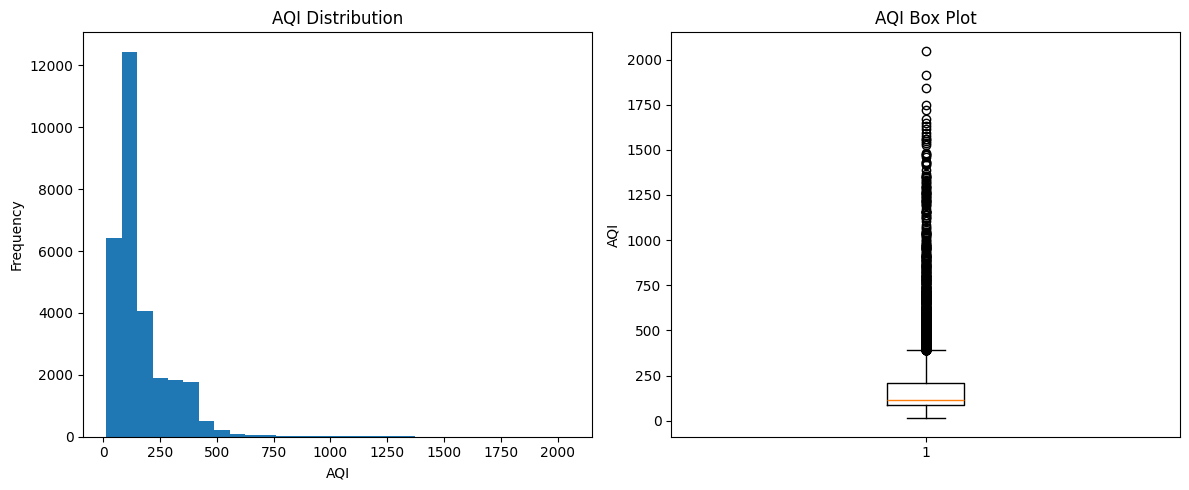

In [177]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(city_clean['AQI'], bins=30)
plt.title("AQI Distribution")
plt.xlabel("AQI")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.boxplot(city_clean['AQI'])
plt.title("AQI Box Plot")
plt.ylabel("AQI")

plt.tight_layout()
plt.show()

The histogram shows that most AQI values are concentrated between about 50 and 250, meaning most cities experience moderate to poor air quality.
The box plot reveals a large number of extreme outliers, with some AQI values exceeding 1000 and even 2000. These unusually high values can increase the average AQI suggesting that the mean may overstate the pollution level of a typical city. A histogram was chosen because it shows where AQI values are clustered and helps determine whether most cities fall into a particular pollution range. A box plot was chosen because it highlights extreme values and outliers.

<b>Task 5</b>

In [178]:
q1 = city_clean['AQI'].quantile(0.25)
q3 = city_clean['AQI'].quantile(0.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = city_clean[
    (city_clean['AQI'] < lower) |
    (city_clean['AQI'] > upper)
]

print("Number of Outliers:", len(outliers))

city_outlier = city_clean.copy()

city_outlier['AQI'] = city_outlier['AQI'].clip(
    lower=lower,
    upper=upper
)

print("Maximum AQI before treatment:", city_clean['AQI'].max())
print("Maximum AQI after treatment :", city_outlier['AQI'].max())

Number of Outliers: 1465
Maximum AQI before treatment: 2049.0
Maximum AQI after treatment : 391.0


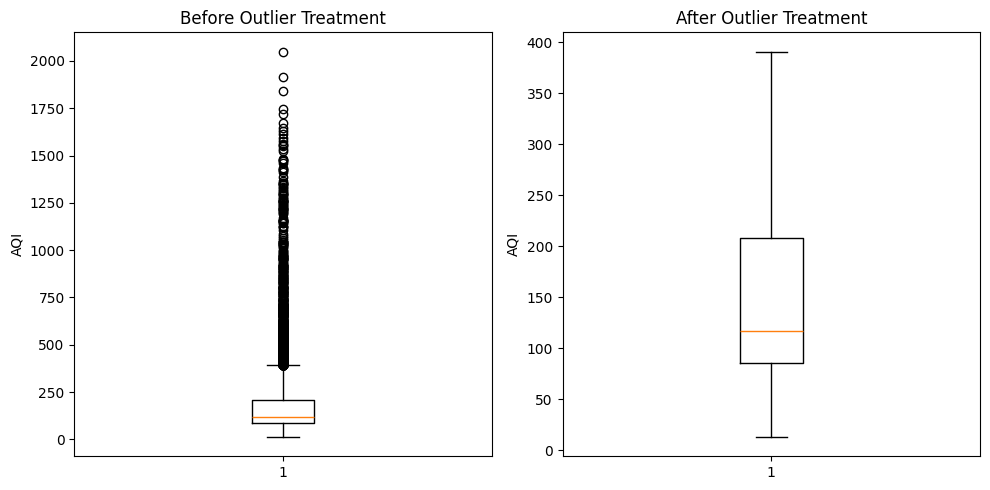

In [179]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.boxplot(city_clean['AQI'])
plt.title("Before Outlier Treatment")
plt.ylabel("AQI")

plt.subplot(1,2,2)
plt.boxplot(city_outlier['AQI'])
plt.title("After Outlier Treatment")
plt.ylabel("AQI")

plt.tight_layout()
plt.show()

The boxplot before treatment shows a large number of extreme AQI values with some observations exceeding 2000. After using IQR method AQI values and capped at IQR upper limit the extreme values were greatly reduced and the maximum AQI dropped to 391.

The method flags any value below Q1 − 1.5×IQR or above Q3 + 1.5×IQR as a statistical outlier.<br>
AQI is heavily right-skewed<br>
IQR is robust to the very outliers it is trying to detect<br> 

<b>Task 6</b>

In [180]:
city_trend = city_outlier.copy()

city_trend['Year'] = city_trend['Date'].dt.year

yearly_aqi = city_trend.groupby('Year')['AQI'].mean().reset_index()
yearly_aqi.columns = ['Year', 'Mean_AQI']

most_polluted = yearly_aqi.loc[yearly_aqi['Mean_AQI'].idxmax()]
least_polluted = yearly_aqi.loc[yearly_aqi['Mean_AQI'].idxmin()]

print(yearly_aqi)

print(f"\nMost polluted year : {int(most_polluted['Year'])} "
      f"(AQI {most_polluted['Mean_AQI']:.2f})")

print(f"Least polluted year: {int(least_polluted['Year'])} "
      f"(AQI {least_polluted['Mean_AQI']:.2f})")

   Year    Mean_AQI
0  2015  185.398072
1  2016  191.520558
2  2017  175.784816
3  2018  160.005718
4  2019  145.420830
5  2020  111.574042

Most polluted year : 2016 (AQI 191.52)
Least polluted year: 2020 (AQI 111.57)


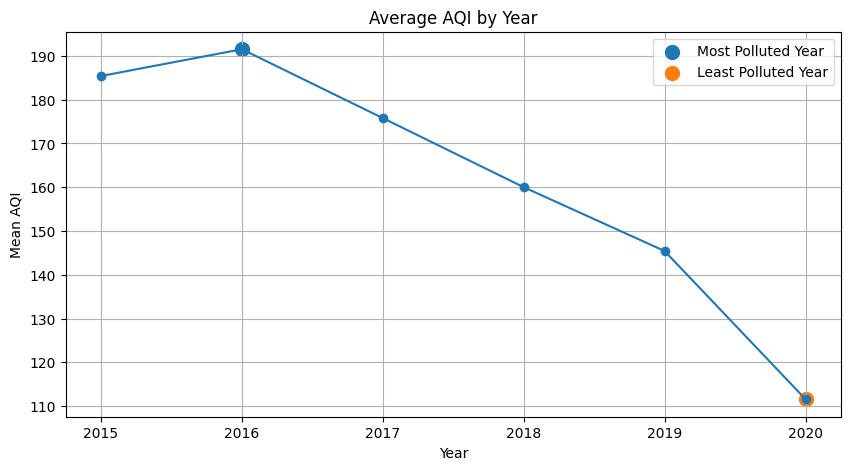

In [181]:
plt.figure(figsize=(10,5))

plt.plot(yearly_aqi['Year'],
         yearly_aqi['Mean_AQI'],
         marker='o')

plt.scatter(most_polluted['Year'],
            most_polluted['Mean_AQI'],
            s=100,
            label='Most Polluted Year')

plt.scatter(least_polluted['Year'],
            least_polluted['Mean_AQI'],
            s=100,
            label='Least Polluted Year')

plt.title('Average AQI by Year')
plt.xlabel('Year')
plt.ylabel('Mean AQI')
plt.grid(True)
plt.legend()

plt.show()

India Air Quality has been improved in last six years although there is a sudden increase in average AQI from 2015 to 2016 but after 2016 the average AQI keeps on constantly decreasing each year recording approx 111.57 in 2020. The most polluted year is 2016 and least is 2020 there is a 42% decrease in average AQI between 2016 and 2020. The decline observed in 2020 may have been influenced by reduced industrial and transportation activity during the COVID-19 lockdowns but the decline had already been started several years earlier suggesting that broader pollution control measures and environmental initiatives may also have contributed to the improvement.

<b>Task 7</b>

In [182]:
season_data = city_outlier.copy()

season_data['Month'] = season_data['Date'].dt.month

monthly_aqi = season_data.groupby('Month')['AQI'].mean().reset_index()
monthly_aqi.columns = ['Month', 'Mean_AQI']

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

monthly_aqi['Month_Name'] = monthly_aqi['Month'].apply(
    lambda x: month_names[x - 1]
)

def season(m):
    if m in [12, 1, 2]:
        return 'Winter (Dec-Feb)'
    elif m in [3, 4, 5]:
        return 'Pre-Monsoon (Mar-May)'
    elif m in [6, 7, 8, 9]:
        return 'Monsoon (Jun-Sep)'
    else:
        return 'Post-Monsoon (Oct-Nov)'

monthly_aqi['Season'] = monthly_aqi['Month'].apply(season)

seasonal_mean = season_data.copy()
seasonal_mean['Season'] = seasonal_mean['Month'].apply(season)

seasonal_mean = (
    seasonal_mean.groupby('Season')['AQI']
    .mean()
    .reset_index()
    .sort_values('AQI', ascending=False)
)

print("Monthly Mean AQI:")
print(monthly_aqi[['Month_Name', 'Mean_AQI', 'Season']].to_string(index=False))

print("\nSeasonal Mean AQI:")
print(seasonal_mean.to_string(index=False))

Monthly Mean AQI:
Month_Name   Mean_AQI                 Season
       Jan 207.696871       Winter (Dec-Feb)
       Feb 184.675824       Winter (Dec-Feb)
       Mar 154.527283  Pre-Monsoon (Mar-May)
       Apr 139.972243  Pre-Monsoon (Mar-May)
       May 138.559731  Pre-Monsoon (Mar-May)
       Jun 124.918534      Monsoon (Jun-Sep)
       Jul 116.608379      Monsoon (Jun-Sep)
       Aug 116.645517      Monsoon (Jun-Sep)
       Sep 119.412333      Monsoon (Jun-Sep)
       Oct 166.974149 Post-Monsoon (Oct-Nov)
       Nov 210.678101 Post-Monsoon (Oct-Nov)
       Dec 208.411304       Winter (Dec-Feb)

Seasonal Mean AQI:
                Season        AQI
      Winter (Dec-Feb) 200.321169
Post-Monsoon (Oct-Nov) 188.522625
 Pre-Monsoon (Mar-May) 144.327551
     Monsoon (Jun-Sep) 119.765366


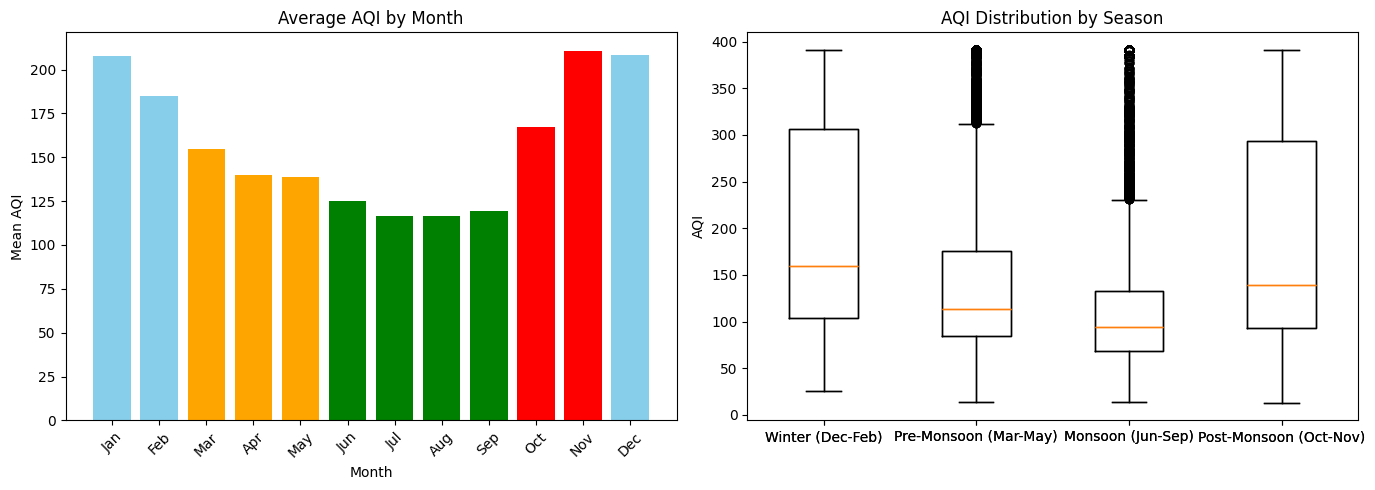

In [183]:
season_colors = {
    'Winter (Dec-Feb)': 'skyblue',
    'Pre-Monsoon (Mar-May)': 'orange',
    'Monsoon (Jun-Sep)': 'green',
    'Post-Monsoon (Oct-Nov)': 'red'
}

plot_df = monthly_aqi.sort_values('Month')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(
    plot_df['Month_Name'],
    plot_df['Mean_AQI'],
    color=plot_df['Season'].map(season_colors)
)

axes[0].set_title('Average AQI by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Mean AQI')
axes[0].tick_params(axis='x', rotation=45)

season_order = [
    'Winter (Dec-Feb)',
    'Pre-Monsoon (Mar-May)',
    'Monsoon (Jun-Sep)',
    'Post-Monsoon (Oct-Nov)'
]
season_df = city_outlier.copy()
season_df['Month'] = season_df['Date'].dt.month

season_data = [
    season_df[season_df['Month'].apply(season) == s]['AQI']
    for s in season_order
]

axes[1].boxplot(season_data, labels=season_order)

axes[1].boxplot(season_data, labels=season_order)

axes[1].set_title('AQI Distribution by Season')
axes[1].set_ylabel('AQI')

plt.tight_layout()
plt.show()

The claim is only partly true. Air pollution is high during the October–November harvest season, with November recording the highest average AQI. Pollution remains almost as severe in December and January showing that the problem extends beyond the harvest period. Monsoon months (June–September) have the cleanest air because rainfall helps remove pollutants from the atmosphere. This suggests that while crop-residue burning contributes to poor air quality winter weather conditions that trap pollutants also play a major role.

<b>Task 8</b>

In [184]:
city_outlier['State'] = city_outlier['City'].map(c_to_s)

city_state = city_outlier.dropna(subset=['State']).copy()
city_state = city_state.groupby('State').agg(
    Mean_AQI  = ('AQI',   'mean'),
    Mean_PM25 = ('PM2.5', 'mean'),
    Mean_NO2  = ('NO2',   'mean'),
    Mean_SO2  = ('SO2',   'mean'),
    Mean_PM10 = ('PM10',  'mean')
).reset_index()

crop_state = crop_merge.copy()
crop_state = crop_state.groupby('State_Name').agg(
    Total_Production = ('Production', 'sum'),
    Total_Area       = ('Area',       'sum')
).reset_index()
crop_state['Yield'] = crop_state['Total_Production'] / crop_state['Total_Area']
crop_state.rename(columns={'State_Name': 'State'}, inplace=True)

merged = pd.merge(city_state, crop_state, on='State', how='inner')
print(f"Merged dataset shape: {merged.shape}")
print(merged[['State', 'Mean_AQI', 'Mean_PM25', 'Yield', 'Total_Production']].to_string(index=False))

Merged dataset shape: (20, 9)
         State   Mean_AQI  Mean_PM25       Yield  Total_Production
Andhra Pradesh 106.463324  42.500396  131.702442      1.732491e+10
         Assam 137.151394  63.651753   30.005695      2.111764e+09
         Bihar 229.776103 117.904634    2.857217      3.665010e+08
    Chandigarh  96.259868  40.742401    5.195376      6.505650e+04
       Gujarat 336.380040  64.889706    3.383944      5.243219e+08
       Haryana 217.997618 114.631751    4.292970      3.846385e+08
     Jharkhand 148.783576  61.837348    1.147661      1.077774e+07
     Karnataka  93.908412  35.463743    4.255281      8.634396e+08
        Kerala  80.608635  27.890564 3067.605766      9.788139e+10
Madhya Pradesh 132.339100  49.897024    1.363072      4.495591e+08
   Maharashtra  96.536585  28.214617    3.922346      1.263804e+09
     Meghalaya  51.832258  28.057742    3.001837      1.211250e+07
       Mizoram  34.557522  17.012301    1.702848      1.692180e+06
        Odisha 151.891841  60.74

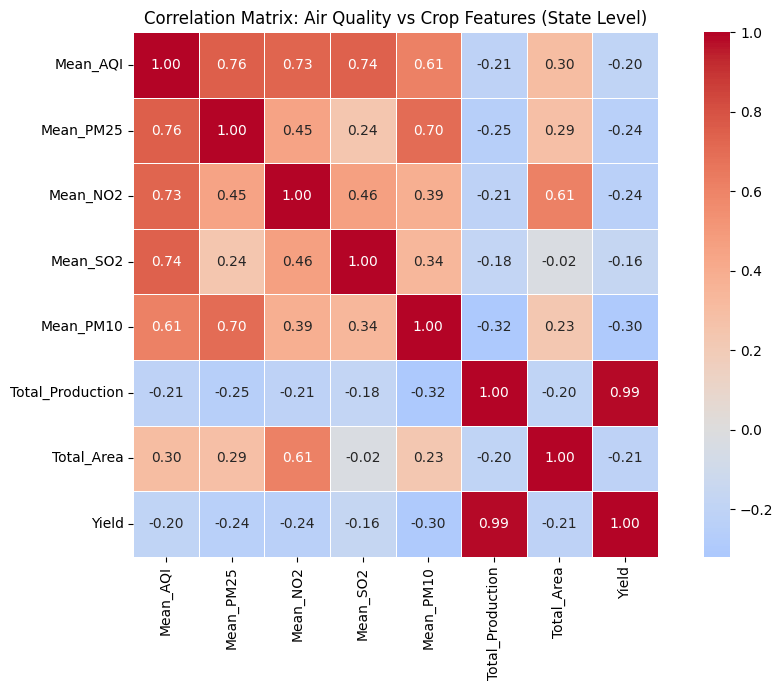

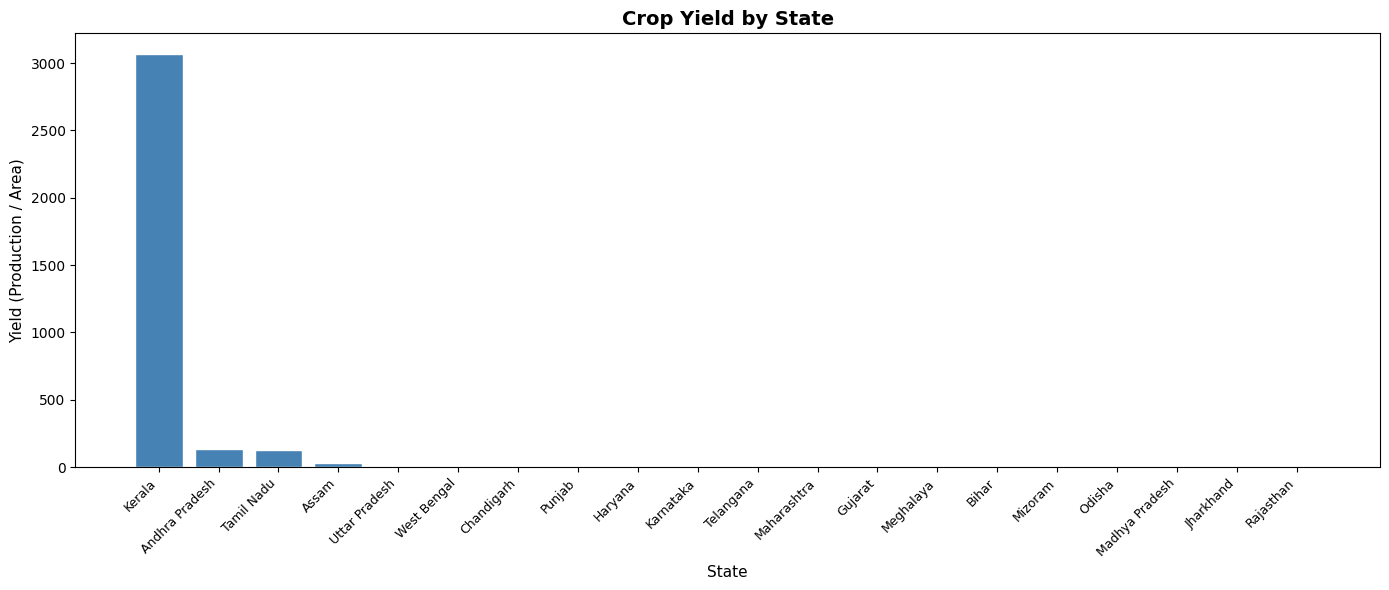

In [185]:
num_cols = ['Mean_AQI', 'Mean_PM25', 'Mean_NO2', 'Mean_SO2', 'Mean_PM10',
            'Total_Production', 'Total_Area', 'Yield']

corr = merged[num_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix: Air Quality vs Crop Features (State Level)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))

sorted_merged = merged.sort_values('Yield', ascending=False)

plt.bar(sorted_merged['State'], sorted_merged['Yield'], color='steelblue', edgecolor='white')

plt.title("Crop Yield by State", fontsize=14, fontweight='bold')
plt.xlabel("State", fontsize=11)
plt.ylabel("Yield (Production / Area)", fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=9)

plt.tight_layout()
plt.show()

Mean_AQI and Mean_NO2 (r = 0.73, strong positive)<br>
States with higher AQI also tend to have higher NO2 levels because NO2 comes mainly from vehicles and power plants states like Delhi,
UP, and Bihar have dense traffic and heavy industry so both AQI and NO2 rise together.<br>

Pollutants vs Yield (r = −0.20 to −0.30 weak negative)<br>
States with worse air quality tend to have slightly lower crop yield. High PM2.5 and PM10 can reduce sunlight reaching crops, and SO2/NO2 contribute to acid rain which degrades soil over time. The correlation is weak though factors like irrigation and rainfall likely matter more. Kerala is an outlier with the lowest AQI 80.6 but highest yield 3067.<br>

A correlation matrix only shows linear relationships between pairs of variables it can not tell if pollution causes lower yield. Correlation does not imply causation.

<b>Task 9</b>

1. India air is getting cleaner: The average pollution level across monitored cities fell by 45% between 2016 and 2020 from a reading of 191 down to 111 on the national scale. This is a meaningful improvement and suggests that measures taken after 2018 are working though the 2020 also played a role.<br>

2. October and November are the worst months every year consistently: Pollution spikes sharply in November average more than double those in July. This pattern repeats every year and aligns with the period of widespread crop residue burning across northern states.<br>

3. states with higher pollution tend to show slightly lower farm output per unit of land: The relationship is weak and not conclusive but it points in the direction one would expect if air pollution is affecting crop health.<br>

Recommended action: Expand real-time air-quality monitoring in agricultural districts during October–November and link it to existing alerts so goverment can deploy enforcement resources where the data shows the worst spikes.<br>

Limitation: The two datasets cover different time periods and different geographic scales. We cannot prove that pollution causes lower yields in these states other factors such as rainfall, soil type, and crop mix also matter.

Conclusion of Lab1 and Lab2<br>
Air Quality Is Improving, But Not Uniformly: India national average AQI dropped from 191 in 2016 to 111 in 2020 a 45% improvement at a rate of roughly 17 AQI points per year.<br>
Air quality follows a clear and repeating seasonal pattern as shown in the AQI distribution plot by season<br>
The data confirms that worsening air quality and lower agricultural yield tend to co-occur at the state leve but does not prove that one causes the other. The association is statistically weak (r = −0.21) and confounded by crop type, geography, and agricultural practices.

<b>Optional Task</b><br>
<b>Task A</b>

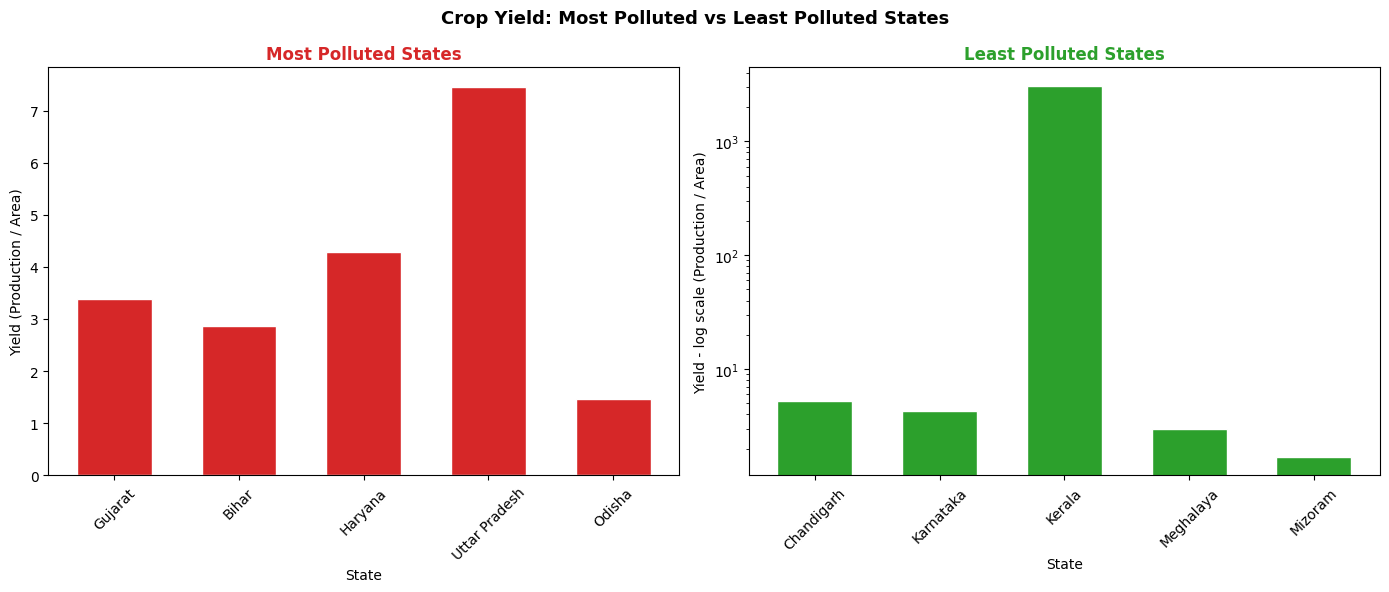

In [186]:
merged_sorted = merged.sort_values('Mean_AQI', ascending=False).reset_index(drop=True)

top5 = merged_sorted.head(5)
bot5 = merged_sorted.tail(5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.bar(top5['State'], top5['Yield'], color='#d62728', edgecolor='white', width=0.6)
ax1.set_title("Most Polluted States", fontsize=12, fontweight='bold', color='#d62728')
ax1.set_xlabel("State")
ax1.set_ylabel("Yield (Production / Area)")
ax1.tick_params(axis='x', rotation=45)

ax2.bar(bot5['State'], bot5['Yield'], color='#2ca02c', edgecolor='white', width=0.6)
ax2.set_yscale('log')
ax2.set_title("Least Polluted States", fontsize=12, fontweight='bold', color='#2ca02c')
ax2.set_xlabel("State")
ax2.set_ylabel("Yield - log scale (Production / Area)")
ax2.tick_params(axis='x', rotation=45)

fig.suptitle("Crop Yield: Most Polluted vs Least Polluted States",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

The hypothesis sate with high pollution cause lower crop yield is not completely rejected or completely accepted because states like (Gujarat, Bihar, Haryana, UP, odisha) are top 5 most polluted states but the crop yield is low to moderate. While states like kerala with low AQI shows an extreme good crop yield but other states like meghalya, mizoram, karnataka, chandigarh does not follow the same approach.

<b>Task B</b>

Correlation (r): -0.2


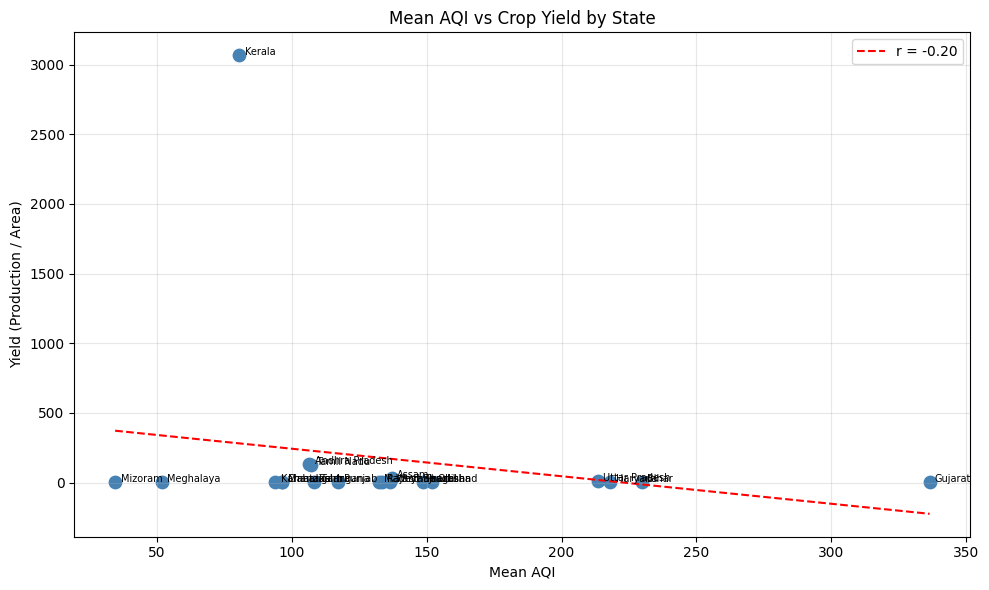

In [187]:
r, _ = stats.pearsonr(merged['Mean_AQI'], merged['Yield'])
print(f"Correlation (r): {round(r, 3)}")

slope, intercept, _, _, _ = stats.linregress(merged['Mean_AQI'], merged['Yield'])
x_line = np.linspace(merged['Mean_AQI'].min(), merged['Mean_AQI'].max(), 100)
y_line = slope * x_line + intercept

plt.figure(figsize=(10, 6))
plt.scatter(merged['Mean_AQI'], merged['Yield'], color='steelblue', s=80)

for _, row in merged.iterrows():
    plt.text(row['Mean_AQI'] + 2, row['Yield'], row['State'], fontsize=7)

plt.plot(x_line, y_line, color='red', linestyle='--', label=f'r = {r:.2f}')

plt.title("Mean AQI vs Crop Yield by State")
plt.xlabel("Mean AQI")
plt.ylabel("Yield (Production / Area)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

A correlation of -0.20 shows weak negative correlation which implies that states with high AQI tends to have low crop yield but the relationship is not strong. The scatter plot shows that apart from pollution other factors also affect crop yield

<b>Task C</b>

The heatmap shows all air quality and crop variables together in one view.Pollutants like AQI, NO2, and PM2.5 are strongly linked to each other
(r = 0.73 to 0.76), but their connection to crop yield is weak (r = −0.20 to −0.30). The pattern points in the expected direction but is not strong enough to prove causation rainfall, irrigation and soil type are not in this dataset and could equally explain the yield differences seen across states.